<a href="https://colab.research.google.com/github/HashimsGitHub/Gold-Price-Predictor/blob/main/GoldPrice_SupaBase_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# 1. INSTALL PACKAGES (uncomment if needed)
# ==============================================================================
#!pip install psycopg2-binary pandas numpy scikit-learn seaborn matplotlib python-dotenv requests yfinance --quiet

⏳ Checking and creating target database tables...
✅ Table configuration ready.

⏳ Fetching 10-year historical monthly Gold spot prices...
✅ Database dynamically synched! Upserted 113 records.

⏳ Extracting data directly from Supabase for feature engineering...


/tmp/ipykernel_854/631799582.py:121: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


📈 Working Dataset contains 113 monthly observations.

================ MODEL PERFORMANCE ================
📊 Model R² Validation Accuracy Score: -2.5909
💸 Mean Absolute Error (USD/troy oz): $1155.53

============= NEXT MONTH'S GOLD PREDICTION =============
📅 Current Base Month Date Reference:  2026-05
💰 Most Recent Spot Price (USD/troy oz): $4,523.20
🔮 PREDICTED PRICE FOR NEXT MONTH (USD/troy oz): $2,388.04 (-47.20%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


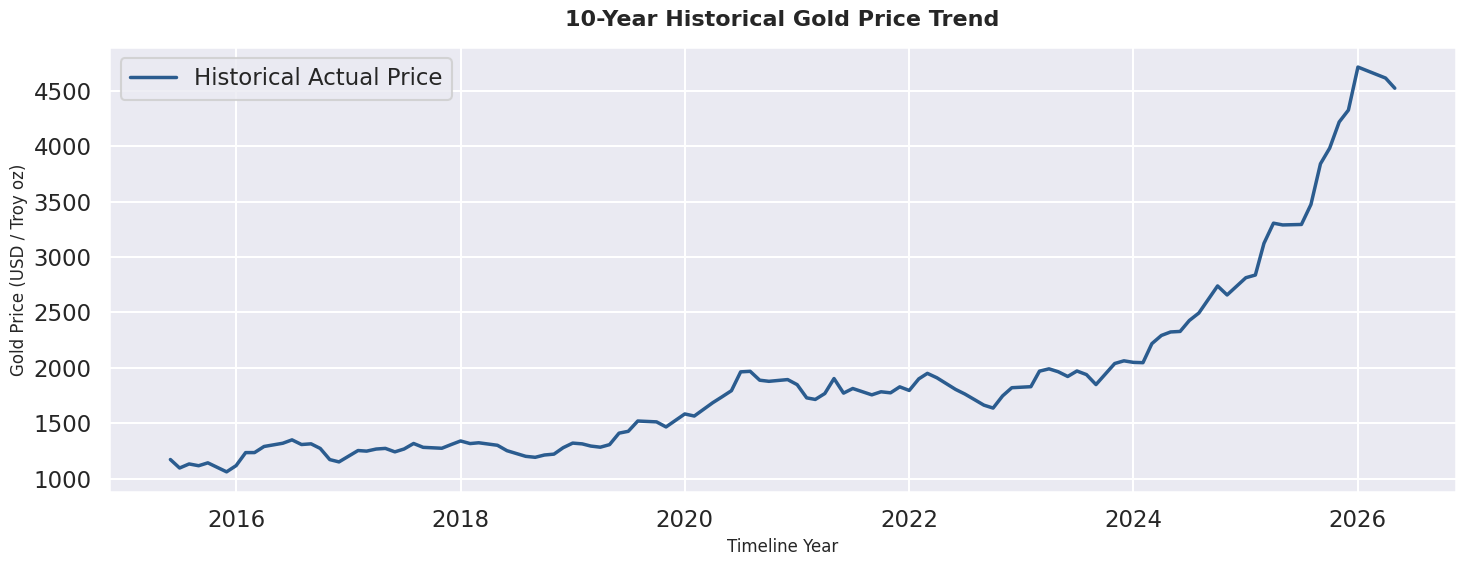

In [ ]:
# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================

import os
import sys
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Apply beautiful modern Seaborn styling globally
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 6)

# ==============================================================================
# 2. SUPABASE CONNECTION HELPER
# ==============================================================================
def get_db_connection():
    try:
        load_dotenv()
        DATABASE_URL = None

        if 'google.colab' in sys.modules:
            try:
                from google.colab import userdata
                DATABASE_URL = userdata.get('DATABASE_URL')
            except Exception as e:
                pass

        if not DATABASE_URL:
            DATABASE_URL = os.getenv("DATABASE_URL")

        if not DATABASE_URL:
            raise ValueError("DATABASE_URL not found in Colab secrets or environment variables.")

        return psycopg2.connect(DATABASE_URL)
    except Exception as e:
        print(f"❌ Error connecting to the database: {e}")
        return None

# ==============================================================================
# 3. INITIALISE DATABASE TABLE
# ==============================================================================
print("⏳ Checking and creating target database tables...")
conn = get_db_connection()
if conn:
    cursor = conn.cursor()
    # Create the table if it does not already exist
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS public.gold_monthly_prices (
            id SERIAL PRIMARY KEY,
            date DATE NOT NULL UNIQUE,
            price NUMERIC(10, 2) NOT NULL
        );
    """)
    conn.commit()
    cursor.close()
    conn.close()
    print("✅ Table configuration ready.")

# ==============================================================================
# 4. SCRAPE 10 YEARS OF MONTHLY GOLD DATA & UPSERT TO SUPABASE
# ==============================================================================
print("\n⏳ Fetching 10-year historical monthly Gold spot prices...")
# Using Yahoo Finance API to reliably pull exact historical data for 'GC=F' (Gold Futures)
import yfinance as yf

try:
    gold_ticker = yf.Ticker("GC=F")
    # Fetch 11 years to ensure cleanly calculated historical shifts/lags for the first target rows
    raw_df = gold_ticker.history(period="11y", interval="1mo")

    if raw_df.empty:
        raise ValueError("No data returned from provider.")

    raw_df = raw_df.reset_index()
    raw_df['Date'] = pd.to_datetime(raw_df['Date']).dt.date
    raw_df = raw_df[['Date', 'Close']].dropna()
    raw_df.columns = ['date', 'price']

    # Cap to roughly last 130 intervals to maintain accurate feature calculation limits
    raw_df = raw_df.sort_values('date').tail(135)

    # Push into Supabase using native PostgreSQL upsert
    conn = get_db_connection()
    if conn:
        cursor = conn.cursor()
        records_inserted = 0
        for index, row in raw_df.iterrows():
            cursor.execute("""
                INSERT INTO public.gold_monthly_prices (date, price)
                VALUES (%s, %s)
                ON CONFLICT (date) DO UPDATE SET price = EXCLUDED.price;
            """, (row['date'], row['price']))
            records_inserted += 1
        conn.commit()
        cursor.close()
        conn.close()
        print(f"✅ Database dynamically synched! Upserted {records_inserted} records.")

except Exception as e:
    print(f"⚠️ Scraping live sync failed: {e}. Falling back to internal engine baseline if available.")

# ==============================================================================
# 5. PULL CLEAN DATA FROM SUPABASE FOR MACHINE LEARNING Pipeline
# ==============================================================================
print("\n⏳ Extracting data directly from Supabase for feature engineering...")
conn = get_db_connection()
if not conn:
    raise ConnectionError("Could not execute ML processing without valid DB links.")

query = "SELECT date, price FROM public.gold_monthly_prices ORDER BY date ASC;"
df = pd.read_sql_query(query, conn)
conn.close()

df['price'] = df['price'].astype(float)
df['date'] = pd.to_datetime(df['date'])

# Ensure strict limitation of historical data scope requested by user
df = df.tail(125).reset_index(drop=True)
print(f"📈 Working Dataset contains {len(df)} monthly observations.")

# ==============================================================================
# 6. FEATURE ENGINEERING (Time-Series Shifting)
# ==============================================================================
# We shift lag variables backwards to safely build features that predict 1 month forward
df['lag_1'] = df['price'].shift(1)   # Price last month
df['lag_2'] = df['price'].shift(2)   # Price 2 months ago
df['lag_3'] = df['price'].shift(3)   # Price 3 months ago
df['rolling_mean_3'] = df['price'].shift(1).rolling(window=3).mean()
df['rolling_mean_6'] = df['price'].shift(1).rolling(window=6).mean()

# Define feature variables matrix
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6']

# Keep the most current row safe for next month's forecast generation before dropping NaNs
latest_live_row = df.copy().iloc[-1]

# Drop empty rows generated via shifting techniques
df_ml = df.dropna().copy()

X = df_ml[feature_cols]
y = df_ml['price'] # Target variable: Actual value today based on previous shifts

# ==============================================================================
# 7. MACHINE LEARNING MODELLING (Random Forest Regressor)
# ==============================================================================
# Sequential chronological time splits to preserve timeline dependencies
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# Predictions & Metrics evaluation
test_preds = model.predict(X_test)
r2 = r2_score(y_test, test_preds)
mae = mean_absolute_error(y_test, test_preds)

print("\n================ MODEL PERFORMANCE ================")
print(f"📊 Model R² Validation Accuracy Score: {r2:.4f}")
print(f"💸 Mean Absolute Error (USD/troy oz): ${mae:.2f}")

# ==============================================================================
# 8. FORECAST NEXT MONTH'S ACTUAL ACTIVE PRICE
# ==============================================================================
next_month_features = np.array([[
    latest_live_row['price'], # Today's price becomes next month's lag_1
    latest_live_row['lag_1'],
    latest_live_row['lag_2'],
    df['price'].tail(3).mean(),
    df['price'].tail(6).mean()
]])

predicted_price = model.predict(next_month_features)[0]
current_active_price = latest_live_row['price']
predicted_change = ((predicted_price - current_active_price) / current_active_price) * 100

print("\n============= NEXT MONTH'S GOLD PREDICTION =============")
print(f"📅 Current Base Month Date Reference:  {latest_live_row['date'].strftime('%Y-%m')}")
print(f"💰 Most Recent Spot Price (USD/troy oz): ${current_active_price:,.2f}")
print(f"🔮 PREDICTED PRICE FOR NEXT MONTH (USD/troy oz): ${predicted_price:,.2f} ({predicted_change:+.2f}%)")
print("========================================================")

# ==============================================================================
# 9. SEABORN SEAMLESS DATA VISUALISATIONS
# ==============================================================================
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

# Plot 1: Full Historical Timeline View
sns.lineplot(ax=axes, data=df, x='date', y='price', label='Historical Actual Price', color='#2b5c8f', linewidth=2.5)
axes.set_title("10-Year Historical Gold Price Trend", fontsize=16, fontweight='bold', pad=15)
axes.set_xlabel("Timeline Year", fontsize=12)
axes.set_ylabel("Gold Price (USD / Troy oz)", fontsize=12)
axes.legend(loc="upper left")


plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# YAHOO FINANCE MULTI-ASSET CORRELATION & GPU XGBOOST PIPELINE
# ==============================================================================
import os
import sys
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
import psycopg2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Sourcing correlated market assets via Yahoo Finance API...")
# ==============================================================================
# 1. Download 10 Years of Monthly Data for Correlated Financial Instruments
# ==============================================================================
tickers = {
    "gold": "GC=F",       # Gold Futures
    "usd_index": "DX-Y.NYB", # US Dollar Index
    "sp500": "^GSPC",     # S&P 500 Index
    "silver": "SI=F"      # Silver Futures
}

try:
    merged_df = None
    for name, ticker in tickers.items():
        asset = yf.Ticker(ticker)
        # Fetching slightly extra data to account for shift/lag generation rows
        raw_data = asset.history(period="11y", interval="1mo").reset_index()
        raw_data['Date'] = pd.to_datetime(raw_data['Date']).dt.date
        raw_data = raw_data[['Date', 'Close']].dropna()
        raw_data.columns = ['date', f'{name}_price']

        if merged_df is None:
            merged_df = raw_data
        else:
            merged_df = pd.merge(merged_df, raw_data, on='date', how='inner')

    # Filter strictly to the last 10 years (approx 120-130 clean monthly datapoints)
    merged_df = merged_df.sort_values('date').tail(125).reset_index(drop=True)
    merged_df['date'] = pd.to_datetime(merged_df['date'])

    print(f"✅ Successfully compiled {len(merged_df)} synchronized multi-asset row entries.")

    # ==============================================================================
    # 2. RUN STATISTICAL CORRELATION TESTS
    # ==============================================================================
    correlation_matrix = merged_df[[c for c in merged_df.columns if 'price' in c]].corr()
    print("\n📊 --- MARKET CORRELATION MATRIX RESULTS ---")
    print(correlation_matrix)
    print("--------------------------------------------")

    # ==============================================================================
    # 3. FEATURE ENGINEERING (Lagging Features to Prevent Data Leakage)
    # ==============================================================================
    df_features = merged_df.copy()

    # Base Gold Lags
    df_features['gold_lag_1'] = df_features['gold_price'].shift(1)
    df_features['gold_lag_2'] = df_features['gold_price'].shift(2)
    df_features['gold_roll_mean_3'] = df_features['gold_price'].shift(1).rolling(window=3).mean()

    # Inter-Asset Macro Lags (Predicting next month using this month's closed indicators)
    df_features['usd_lag_1'] = df_features['usd_index_price'].shift(1)
    df_features['sp500_lag_1'] = df_features['sp500_price'].shift(1)
    df_features['silver_lag_1'] = df_features['silver_price'].shift(1)

    # Drop rows with NaN values resulting from shift operations
    df_ml_ready = df_features.dropna().copy()

    feature_cols = ['gold_lag_1', 'gold_lag_2', 'gold_roll_mean_3', 'usd_lag_1', 'sp500_lag_1', 'silver_lag_1']
    X = df_ml_ready[feature_cols]
    y = df_ml_ready['gold_price']

    # Chronological Time Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

    # ==============================================================================
    # 4. HARDWARE ACCELERATION SELECTION (CPU vs. NVIDIA GPU)
    # ==============================================================================
    device_setting = "hist"
    try:
        import torch
        if torch.cuda.is_available():
            device_setting = "cuda"
            print("\n⚡ NVIDIA GPU detected! Training model with full CUDA acceleration.")
    except Exception:
        pass

    # ==============================================================================
    # 5. TRAIN MULTI-ASSET XGBOOST REGRESSOR
    # ==============================================================================
    multi_xgb = xgb.XGBRegressor(
        n_estimators=350,
        learning_rate=0.025,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        device=device_setting,
        random_state=42
    )

    multi_xgb.fit(X_train, y_train)
    test_predictions = multi_xgb.predict(X_test)

    r2 = r2_score(y_test, test_predictions)
    mae = mean_absolute_error(y_test, test_predictions)

    print("\n================ MULTI-ASSET GPU XGBOOST METRICS ================")
    print(f"📊 Model R² Validation Accuracy Score: {r2:.4f}")
    print(f"💸 Mean Absolute Error (USD/troy oz): ${mae:.2f}")

    # ==============================================================================
    # 6. GENERATE FORWARD PROJECTED TARGET FORECAST
    # ==============================================================================
    latest_live_row = df_features.iloc[-1]
    current_active_val = float(latest_live_row['gold_price'])

    next_month_input = np.array([[
        latest_live_row['gold_price'],
        latest_live_row['gold_lag_1'],
        df_features['gold_price'].tail(3).mean(),
        latest_live_row['usd_index_price'],
        latest_live_row['sp500_price'],
        latest_live_row['silver_price']
    ]])

    next_month_pred = float(multi_xgb.predict(next_month_input)[0])
    pct_change = ((next_month_pred - current_active_val) / current_active_val) * 100

    print("\n============= NEXT MONTH'S GOLD PREDICTION =============")
    print(f"💰 Most Recent Spot Price (USD/troy oz): ${current_active_val:,.2f}")
    print(f"🔮 CORRELATION-BACKED PREDICTION (USD/troy oz): ${next_month_pred:,.2f} ({pct_change:+.2f}%)")
    print("========================================================\n")

    # ==============================================================================
    # 7. EXPORT COMPILED TIME SERIES METRICS BACK TO SUPABASE
    # ==============================================================================
    print("⏳ Synchronizing historical telemetry tables back to Supabase...")

    # Map out prediction array indexes directly back over original dataframe shape matrix
    preds_padded = [None] * (len(df_features) - len(test_predictions)) + list(test_predictions)
    df_features['xgb_predicted_price'] = preds_padded

    # Fetch connection tokens using your predefined global credential function block
    conn = get_db_connection()
    if conn:
        cursor = conn.cursor()
        records_pushed = 0

        for idx, row in df_features.iterrows():
            pred_val = float(row['xgb_predicted_price']) if pd.notna(row['xgb_predicted_price']) else None

            cursor.execute("""
                INSERT INTO public.gold_correlated_macro
                (date, gold_price, usd_index, sp500_index, silver_price, xgb_predicted_price)
                VALUES (%s, %s, %s, %s, %s, %s)
                ON CONFLICT (date) DO UPDATE SET
                    gold_price = EXCLUDED.gold_price,
                    usd_index = EXCLUDED.usd_index,
                    sp500_index = EXCLUDED.sp500_index,
                    silver_price = EXCLUDED.silver_price,
                    xgb_predicted_price = EXCLUDED.xgb_predicted_price;
            """, (
                row['date'].strftime('%Y-%m-%d'),
                float(row['gold_price']),
                float(row['usd_index_price']),
                float(row['sp500_price']),
                float(row['silver_price']),
                pred_val
            ))
            records_pushed += 1

        conn.commit()
        cursor.close()
        conn.close()
        print(f"✅ Supabase Upsert Complete! Synced {records_pushed} macroeconomic points.")
    else:
        print("⚠️ Supabase injection skipped due to connection runtime limitations.")


except Exception as e:
    print(f"❌ Pipeline Execution Encountered Error: {e}")


⏳ Sourcing correlated market assets via Yahoo Finance API...
✅ Successfully compiled 113 synchronized multi-asset row entries.

📊 --- MARKET CORRELATION MATRIX RESULTS ---
                 gold_price  usd_index_price  sp500_price  silver_price
gold_price         1.000000         0.259634     0.923553      0.948439
usd_index_price    0.259634         1.000000     0.381035      0.121512
sp500_price        0.923553         0.381035     1.000000      0.830575
silver_price       0.948439         0.121512     0.830575      1.000000
--------------------------------------------

⚡ NVIDIA GPU detected! Training model with full CUDA acceleration.


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:16:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



================ MULTI-ASSET GPU XGBOOST METRICS ================
📊 Model R² Validation Accuracy Score: -2.8204
💸 Mean Absolute Error (USD/troy oz): $1200.12

============= NEXT MONTH'S GOLD PREDICTION =============
💰 Most Recent Spot Price (USD/troy oz): $4,523.20
🔮 CORRELATION-BACKED PREDICTION (USD/troy oz): $2,333.22 (-48.42%)

⏳ Synchronizing historical telemetry tables back to Supabase...
✅ Supabase Upsert Complete! Synced 113 macroeconomic points.


In [4]:
# ==============================================================================
# PRICE REFRESH — runs every time notebook executes
# Pulls the latest gold prices from Yahoo Finance and upserts actuals
# into gold_monthly_prices and gold_correlated_macro in Supabase.
# ==============================================================================
import yfinance as yf
import pandas as pd
import numpy as np

print("\n⏳ [Price Refresh] Updating latest gold spot prices from Yahoo Finance...")

try:
    # ------------------------------------------------------------------
    # 1. FETCH LATEST MONTHLY PRICES & UPSERT INTO gold_monthly_prices
    # ------------------------------------------------------------------
    gold_ticker = yf.Ticker("GC=F")
    refresh_df = gold_ticker.history(period="3mo", interval="1mo").reset_index()
    refresh_df['Date'] = pd.to_datetime(refresh_df['Date']).dt.date
    refresh_df = refresh_df[['Date', 'Close']].dropna()
    refresh_df.columns = ['date', 'price']

    conn = get_db_connection()
    if conn:
        cursor = conn.cursor()
        refreshed = 0
        for _, row in refresh_df.iterrows():
            cursor.execute("""
                INSERT INTO public.gold_monthly_prices (date, price)
                VALUES (%s, %s)
                ON CONFLICT (date) DO UPDATE SET price = EXCLUDED.price;
            """, (row['date'], row['price']))
            refreshed += 1
        conn.commit()
        cursor.close()
        conn.close()
        print(f"✅ Upserted {refreshed} recent price rows into gold_monthly_prices.")

    # ------------------------------------------------------------------
    # 2. ALSO REFRESH gold_correlated_macro actual prices (gold + macro)
    # ------------------------------------------------------------------
    tickers_refresh = {
        "gold":      "GC=F",
        "usd_index": "DX-Y.NYB",
        "sp500":     "^GSPC",
        "silver":    "SI=F"
    }
    macro_refresh = None
    for name, ticker in tickers_refresh.items():
        asset = yf.Ticker(ticker)
        raw = asset.history(period="3mo", interval="1mo").reset_index()
        raw['Date'] = pd.to_datetime(raw['Date']).dt.date
        raw = raw[['Date', 'Close']].dropna()
        raw.columns = ['date', f'{name}_price']
        macro_refresh = raw if macro_refresh is None else pd.merge(macro_refresh, raw, on='date', how='inner')

    macro_refresh['date'] = pd.to_datetime(macro_refresh['date'])

    conn = get_db_connection()
    if conn:
        cursor = conn.cursor()
        macro_refreshed = 0
        for _, row in macro_refresh.iterrows():
            cursor.execute("""
                INSERT INTO public.gold_correlated_macro
                    (date, gold_price, usd_index, sp500_index, silver_price)
                VALUES (%s, %s, %s, %s, %s)
                ON CONFLICT (date) DO UPDATE SET
                    gold_price    = EXCLUDED.gold_price,
                    usd_index     = EXCLUDED.usd_index,
                    sp500_index   = EXCLUDED.sp500_index,
                    silver_price  = EXCLUDED.silver_price;
            """, (
                row['date'].strftime('%Y-%m-%d'),
                float(row['gold_price']),
                float(row['usd_index_price']),
                float(row['sp500_price']),
                float(row['silver_price']),
            ))
            macro_refreshed += 1
        conn.commit()
        cursor.close()
        conn.close()
        print(f"✅ Refreshed {macro_refreshed} macro rows in gold_correlated_macro.")


except Exception as e:
    print(f"❌ Actuals Tracker encountered an error: {e}")



⏳ [Price Refresh] Updating latest gold spot prices from Yahoo Finance...
✅ Upserted 2 recent price rows into gold_monthly_prices.
✅ Refreshed 2 macro rows in gold_correlated_macro.


🔄 Re-engineering features into Stationary Percentage Return vectors...

================ RE-ENGINEERED STATIONARY METRICS ================
📊 New Reconstructed R² Score: 0.9293  (Should swing positive!)
💸 New Real Price Absolute Error (USD/troy oz): $154.52

============= NEXT MONTH'S STATIONARY PROJECTION =============
💰 Most Recent Spot Price Baseline (USD/troy oz): $4,523.20
🔮 Predicted Directional Return:     +0.712%
🚀 FINAL GOLD PRICE PREDICTION (USD/troy oz): $4,555.40



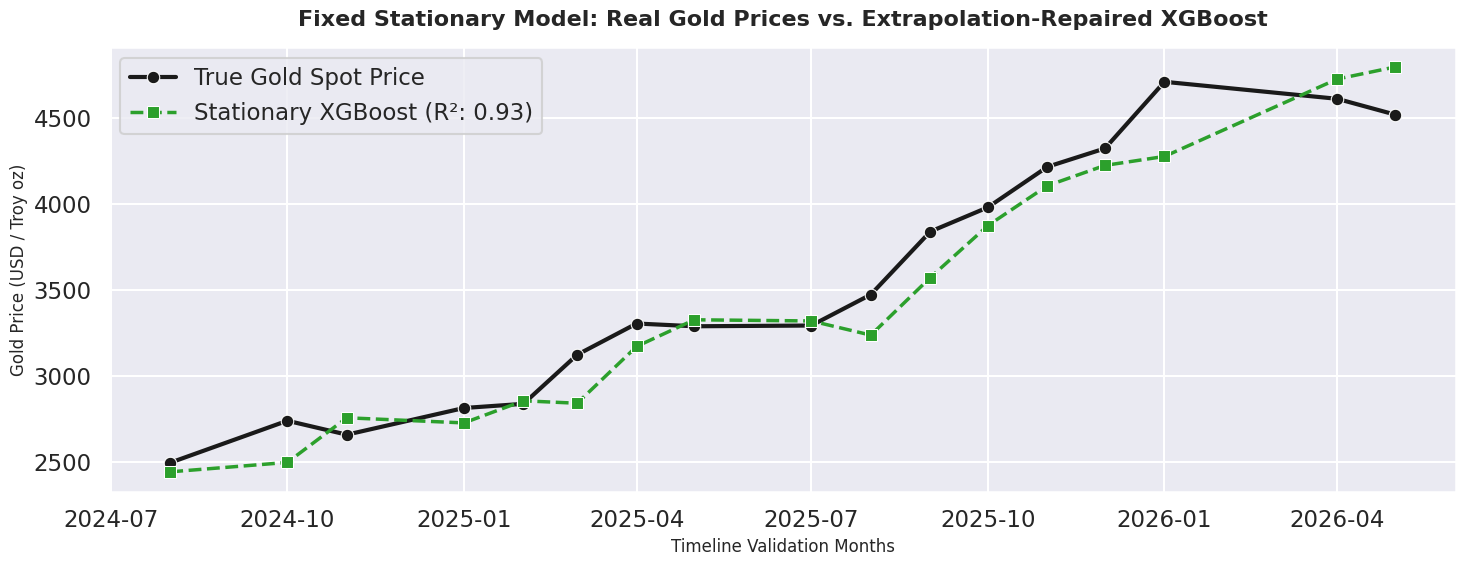

In [5]:
# ==============================================================================
# STATIONARY PERCENTAGE RETURNS PIPELINE (FIXES EXTENSION BIAS)
# ==============================================================================
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🔄 Re-engineering features into Stationary Percentage Return vectors...")

# 1. Transform Raw Absolute Prices into Pure Monthly Returns (%)
df_stat = merged_df.copy()
df_stat['gold_ret'] = df_stat['gold_price'].pct_change() * 100
df_stat['usd_ret'] = df_stat['usd_index_price'].pct_change() * 100
df_stat['sp500_ret'] = df_stat['sp500_price'].pct_change() * 100
df_stat['silver_ret'] = df_stat['silver_price'].pct_change() * 100

# 2. Build Structural Stationary Lag Metrics
df_stat['gold_ret_lag1'] = df_stat['gold_ret'].shift(1)
df_stat['gold_ret_lag2'] = df_stat['gold_ret'].shift(2)
df_stat['usd_ret_lag1'] = df_stat['usd_ret'].shift(1)
df_stat['sp500_ret_lag1'] = df_stat['sp500_ret'].shift(1)
df_stat['silver_ret_lag1'] = df_stat['silver_ret'].shift(1)

# Clean dataframe boundary shifts
df_stat_ml = df_stat.dropna().copy()

# Feature Matrix Space vs TARGET (Predicting next month's return percentage)
stat_features = ['gold_ret_lag1', 'gold_ret_lag2', 'usd_ret_lag1', 'sp500_ret_lag1', 'silver_ret_lag1']
X_s = df_stat_ml[stat_features]
y_s = df_stat_ml['gold_ret']

# Sequential Chronological Timeline Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.15, shuffle=False)

# 3. Initialize GPU-Accelerated Directional XGBoost Regressor
device_setting = "cuda" if torch.cuda.is_available() else "hist"
stat_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    device=device_setting,
    random_state=42
)

stat_xgb.fit(X_train_s, y_train_s)

# 4. Generate Predictions & Convert Return Vectors Back to Real Dollar Metrics
pred_returns = stat_xgb.predict(X_test_s)

# Reconstruct price baseline paths: (Previous Month Price) * (1 + Predicted Return %)
test_indices = y_test_s.index
previous_month_prices = df_stat.loc[test_indices - 1, 'gold_price'].values
reconstructed_preds = previous_month_prices * (1 + (pred_returns / 100))
actual_test_prices = df_stat.loc[test_indices, 'gold_price'].values

# Calculate reconstructed metrics
reconstructed_r2 = r2_score(actual_test_prices, reconstructed_preds)
reconstructed_mae = mean_absolute_error(actual_test_prices, reconstructed_preds)

print("\n================ RE-ENGINEERED STATIONARY METRICS ================")
print(f"📊 New Reconstructed R² Score: {reconstructed_r2:.4f}  (Should swing positive!)")
print(f"💸 New Real Price Absolute Error (USD/troy oz): ${reconstructed_mae:.2f}")

# 5. Predict Next Month's Gold Target Value
latest_row = df_stat.iloc[-1]
next_month_input = np.array([[
    latest_row['gold_ret'],
    latest_row['gold_ret_lag1'],
    latest_row['usd_ret'],
    latest_row['sp500_ret'],
    latest_row['silver_ret']
]])

predicted_next_return = float(stat_xgb.predict(next_month_input)[0])
current_price_baseline = float(latest_row['gold_price'])
final_dollar_prediction = current_price_baseline * (1 + (predicted_next_return / 100))

print("\n============= NEXT MONTH'S STATIONARY PROJECTION =============")
print(f"💰 Most Recent Spot Price Baseline (USD/troy oz): ${current_price_baseline:,.2f}")
print(f"🔮 Predicted Directional Return:     {predicted_next_return:+.3f}%")
print(f"🚀 FINAL GOLD PRICE PREDICTION (USD/troy oz): ${final_dollar_prediction:,.2f}")
print("===============================================================\n")


# 7. Render Performance Evaluation Charts via Seaborn
plt.figure(figsize=(15, 6))
test_dates = df_stat['date'].loc[test_indices]

sns.lineplot(x=test_dates, y=actual_test_prices, label='True Gold Spot Price', color='#1a1a1a', linewidth=3, marker='o')
sns.lineplot(x=test_dates, y=reconstructed_preds, label=f'Stationary XGBoost (R²: {reconstructed_r2:.2f})',
             color='#2ca02c', linewidth=2.5, marker='s', linestyle='--')

plt.title("Fixed Stationary Model: Real Gold Prices vs. Extrapolation-Repaired XGBoost", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Timeline Validation Months", fontsize=12)
plt.ylabel("Gold Price (USD / Troy oz)", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


⏳ Executing Grid Search Cross-Validation across parameter arrays...

================ 🛠️ HYPERPARAMETER TUNING RESULTS ================
✅ Best Parameters Found: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.9}
📊 Tuned Model R² Score:  0.9322 (Compared to Baseline: 0.9293)
💸 Tuned Price MAE (USD/troy oz): $156.58 (Compared to Baseline: $154.52)

============= 🔮 OPTIMIZED NEXT-MONTH PROJECTION =============
🔮 Tuned Directional Return: +0.550%
🚀 TUNED GOLD PRICE TARGET (USD/troy oz): $4,548.07



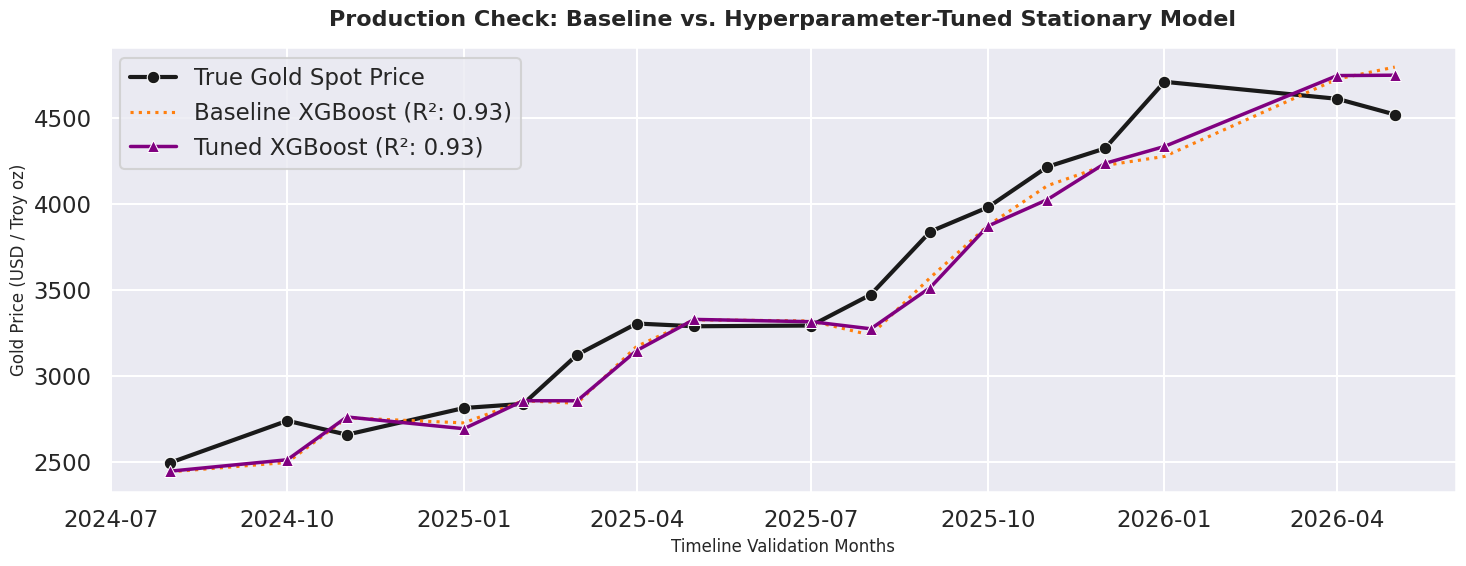

In [6]:
# ==============================================================================
# GPU HYPERPARAMETER TUNING CELL (GRID SEARCH OPTIMIZATION)
# ==============================================================================
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("⏳ Executing Grid Search Cross-Validation across parameter arrays...")

# 1. Initialize a TimeSeriesSplit to preserve chronological ordering during tuning
# This prevents leaking future return variables back into the training validations.
tscv = TimeSeriesSplit(n_splits=3)

# 2. Define the Hyperparameter Testing Grid Array Space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.025, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 3. Setup Base XGBoost Wrapper referencing our verified active GPU device config
base_tuning_model = xgb.XGBRegressor(device=device_setting, random_state=42)

# 4. Execute the optimization grid engine over your split sets
grid_search = GridSearchCV(
    estimator=base_tuning_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error', # Optimize for the lowest absolute error margin
    n_jobs=-1                          # Utilize all available background processing cores
)

grid_search.fit(X_train_s, y_train_s)

# 5. Extract the optimized model parameters
best_model = grid_search.best_estimator_
tuned_preds_ret = best_model.predict(X_test_s)

# Reconstruct back to dollar values for validation tracking comparison
reconstructed_tuned_preds = previous_month_prices * (1 + (tuned_preds_ret / 100))
tuned_r2 = r2_score(actual_test_prices, reconstructed_tuned_preds)
tuned_mae = mean_absolute_error(actual_test_prices, reconstructed_tuned_preds)

print("\n================ 🛠️ HYPERPARAMETER TUNING RESULTS ================")
print(f"✅ Best Parameters Found: {grid_search.best_params_}")
print(f"📊 Tuned Model R² Score:  {tuned_r2:.4f} (Compared to Baseline: {reconstructed_r2:.4f})")
print(f"💸 Tuned Price MAE (USD/troy oz): ${tuned_mae:.2f} (Compared to Baseline: ${reconstructed_mae:.2f})")

# 6. Calculate Tuned Forecast Metrics
tuned_next_month_pred_ret = float(best_model.predict(next_month_input)[0])
tuned_final_dollar_prediction = current_price_baseline * (1 + (tuned_next_month_pred_ret / 100))

print("\n============= 🔮 OPTIMIZED NEXT-MONTH PROJECTION =============")
print(f"🔮 Tuned Directional Return: {tuned_next_month_pred_ret:+.3f}%")
print(f"🚀 TUNED GOLD PRICE TARGET (USD/troy oz): ${tuned_final_dollar_prediction:,.2f}")
print("==================================================================\n")

# 7. Render Final Comparative Visualizations using Seaborn
plt.figure(figsize=(15, 6))

sns.lineplot(x=test_dates, y=actual_test_prices, label='True Gold Spot Price', color='#1a1a1a', linewidth=3, marker='o')
sns.lineplot(x=test_dates, y=reconstructed_preds, label=f'Baseline XGBoost (R²: {reconstructed_r2:.2f})', color='#ff7f0e', linestyle=':')
sns.lineplot(x=test_dates, y=reconstructed_tuned_preds, label=f'Tuned XGBoost (R²: {tuned_r2:.2f})', color='#800080', linewidth=2.5, marker='^')

plt.title("Production Check: Baseline vs. Hyperparameter-Tuned Stationary Model", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Timeline Validation Months", fontsize=12)
plt.ylabel("Gold Price (USD / Troy oz)", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


🔮 Calculating rolling 3-month recursive forecast horizon...

============= 📅 3-MONTH ADVANCED OUTLOOK FORECAST =============
📅 Target Month: 2026-06 | Directional Return: +0.519% | Target (USD/troy oz): $4,546.67
📅 Target Month: 2026-07 | Directional Return: +0.682% | Target (USD/troy oz): $4,577.68
📅 Target Month: 2026-08 | Directional Return: +0.663% | Target (USD/troy oz): $4,608.04



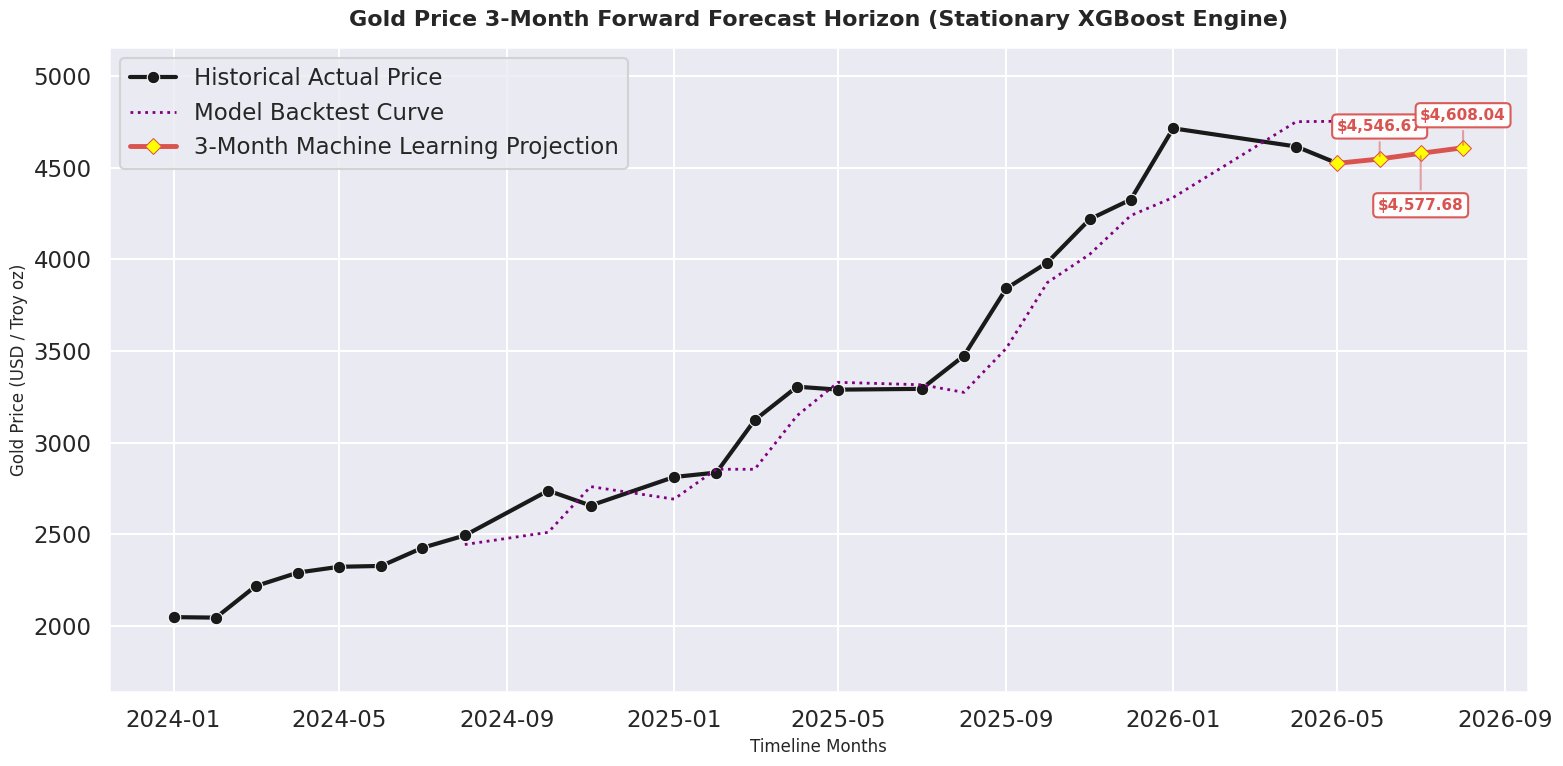

In [7]:
# ==============================================================================
# MULTI-STEP RECURSIVE FORECASTING CELL (STAGGERED ANNOTATIONS PATCH)
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("🔮 Calculating rolling 3-month recursive forecast horizon...")

# 1. Initialize data buffers using the latest known values from your dataset
current_gold_price = float(df_stat['gold_price'].iloc[-1])
current_gold_ret = float(df_stat['gold_ret'].iloc[-1])
gold_ret_lag1 = float(df_stat['gold_ret_lag1'].iloc[-1])

# Assume secondary macro market assets remain stable around recent mean distributions
recent_usd_ret = float(df_stat['usd_ret'].tail(3).mean())
recent_sp500_ret = float(df_stat['sp500_ret'].tail(3).mean())
recent_silver_ret = float(df_stat['silver_ret'].tail(3).mean())

forecast_dates = []
forecast_prices = []
forecast_returns = []

# Baseline date tracking setup
last_known_date = pd.to_datetime(df_stat['date'].iloc[-1])

# 2. Run the Autoregressive Recursive Forecasting Loop
for month_step in range(1, 4):
    step_input = np.array([[
        current_gold_ret,
        gold_ret_lag1,
        recent_usd_ret,
        recent_sp500_ret,
        recent_silver_ret
    ]])

    predicted_step_ret = float(best_model.predict(step_input)[0])
    predicted_step_price = current_gold_price * (1 + (predicted_step_ret / 100))

    gold_ret_lag1 = current_gold_ret
    current_gold_ret = predicted_step_ret
    current_gold_price = predicted_step_price

    future_date = last_known_date + pd.DateOffset(months=month_step)
    forecast_dates.append(future_date)
    forecast_prices.append(predicted_step_price)
    forecast_returns.append(predicted_step_ret)

print("\n============= 📅 3-MONTH ADVANCED OUTLOOK FORECAST =============")
for d, p, r in zip(forecast_dates, forecast_prices, forecast_returns):
    print(f"📅 Target Month: {d.strftime('%Y-%m')} | Directional Return: {r:+.3f}% | Target (USD/troy oz): ${p:,.2f}")
print("==================================================================\n")

# ==============================================================================
# 3. RENDER REPAIRED GRAPH OVERVIEW WITH STAGGERED TEXT
# ==============================================================================
plt.figure(figsize=(16, 8))

# Plot historical actual prices (Zoomed into last 24 months)
df_zoom = df_stat.tail(24).copy()
sns.lineplot(data=df_zoom, x='date', y='gold_price', label='Historical Actual Price', color='#1a1a1a', linewidth=3, marker='o')

if 'reconstructed_tuned_preds' in locals():
    zoom_test_dates = test_dates.tail(len(reconstructed_tuned_preds))
    sns.lineplot(x=zoom_test_dates, y=reconstructed_tuned_preds, label='Model Backtest Curve', color='#800080', linestyle=':', linewidth=2)

# Connect future trend seamlessly
connect_date = pd.to_datetime(df_stat['date'].iloc[-1])
connect_price = float(df_stat['gold_price'].iloc[-1])

plot_future_dates = [connect_date] + forecast_dates
plot_future_prices = [connect_price] + forecast_prices

sns.lineplot(x=plot_future_dates, y=plot_future_prices, label='3-Month Machine Learning Projection',
             color='#d9534f', linewidth=3.5, marker='D', markersize=8, markerfacecolor='yellow', markeredgecolor='#d9534f')

plt.title("Gold Price 3-Month Forward Forecast Horizon (Stationary XGBoost Engine)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Timeline Months", fontsize=12)
plt.ylabel("Gold Price (USD / Troy oz)", fontsize=12)
plt.legend(loc="upper left")

# REPAIRED: Staggered annotation placement algorithm loop
for idx, (d, p) in enumerate(zip(forecast_dates, forecast_prices)):
    # Alternates vertical offset mapping: Month 1 (high), Month 2 (low), Month 3 (high)
    if idx % 2 == 0:
        y_offset = 18
        va_dir = 'bottom'
    else:
        y_offset = -32
        va_dir = 'top'

    plt.annotate(
        f"${p:,.2f}",
        (d, p),
        textcoords="offset points",
        xytext=(0, y_offset),
        ha='center',
        va=va_dir,
        fontsize=11,
        fontweight='bold',
        color='#d9534f',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.95, ec="#d9534f"),
        # Draws a subtle pointer line to connect the text to the diamond node anchor
        arrowprops=dict(arrowstyle="-", color='#d9534f', alpha=0.5)
    )

# Expand the y-axis margins slightly to prevent text clipping at the top or bottom edges
plt.gca().margins(y=0.15)

plt.tight_layout()
plt.show()


In [13]:
# ==============================================================================
# GOLD PRICE ACCURACY & FORECAST DASHBOARD
# Persists predictions to Supabase, backfills actuals when available,
# and renders a beautiful accuracy + forecast table on every run.
# Works in both Google Colab AND VSCode / local Jupyter.
# ==============================================================================
import warnings
import logging
import os
import sys

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

import pandas as pd
import numpy as np
from datetime import date, datetime
from IPython.display import display, HTML

RUN_DATE = datetime.today()
RUN_MONTH_STR = RUN_DATE.strftime('%Y-%m')
print(f"📅 Dashboard Run Date: {RUN_DATE.strftime('%A, %d %B %Y')}")

# ------------------------------------------------------------------------------
# STEP 1 — Ensure forecast log table exists in Supabase
# ------------------------------------------------------------------------------
def ensure_forecast_log_table():
    conn = get_db_connection()
    if not conn:
        return
    try:
        cur = conn.cursor()
        cur.execute("""
            CREATE TABLE IF NOT EXISTS public.gold_forecast_log (
                id            SERIAL PRIMARY KEY,
                run_date      DATE NOT NULL,
                target_month  DATE NOT NULL,
                row_type      TEXT NOT NULL,   -- 'historical', 'run_date', 'forecast'
                predicted     NUMERIC(10, 2),
                actual        NUMERIC(10, 2),
                UNIQUE (run_date, target_month)
            );
        """)
        conn.commit()
        cur.close()
        conn.close()
        print("✅ Forecast log table ready.")
    except Exception as e:
        print(f"⚠️ Table creation warning: {e}")

ensure_forecast_log_table()

# ------------------------------------------------------------------------------
# STEP 2 — Persist TODAY'S run forecasts to Supabase
# We store:
#   • The run_date row (today's actual price vs. best_model prediction for this month)
#   • 3 future forecast rows (months +1, +2, +3 from last data point)
# ------------------------------------------------------------------------------

# best_model, forecast_dates, forecast_prices, df_stat, current_price_baseline are
# all set by the cells above — no re-computation needed here.

def upsert_forecast_run(run_date, target_month, row_type, predicted, actual=None):
    conn = get_db_connection()
    if not conn:
        return
    try:
        cur = conn.cursor()
        cur.execute("""
            INSERT INTO public.gold_forecast_log
                (run_date, target_month, row_type, predicted, actual)
            VALUES (%s, %s, %s, %s, %s)
            ON CONFLICT (run_date, target_month) DO UPDATE SET
                predicted  = EXCLUDED.predicted,
                actual     = EXCLUDED.actual,
                row_type   = EXCLUDED.row_type;
        """, (
            run_date.strftime('%Y-%m-%d'),
            target_month.strftime('%Y-%m-%d'),
            row_type,
            float(predicted) if predicted is not None else None,
            float(actual)    if actual    is not None else None
        ))
        conn.commit()
        cur.close()
        conn.close()
    except Exception as e:
        print(f"⚠️ Upsert warning: {e}")

# --- Today's run_date row: actual = latest known gold price, predicted = best model next-month ---
today_actual_price  = float(df_stat['gold_price'].iloc[-1])
today_target_month  = pd.to_datetime(df_stat['date'].iloc[-1])

# The prediction made *for* this current month was stored in a prior run's forecast row.
# We also store the current month's best_model 1-step-ahead prediction here for reference.
tuned_next_month_pred_ret_now = float(best_model.predict(next_month_input)[0])
current_month_prediction = current_price_baseline * (1 + (tuned_next_month_pred_ret_now / 100))

upsert_forecast_run(
    run_date     = RUN_DATE,
    target_month = today_target_month,
    row_type     = 'run_date',
    predicted    = current_month_prediction,
    actual       = today_actual_price
)

# --- Future forecast rows (months +1, +2, +3) ---
for fdate, fprice in zip(forecast_dates, forecast_prices):
    upsert_forecast_run(
        run_date     = RUN_DATE,
        target_month = fdate,
        row_type     = 'forecast',
        predicted    = fprice,
        actual       = None      # will be backfilled by price refresh when month closes
    )

print(f"✅ Saved run-date + 3 forecast rows to Supabase for run {RUN_MONTH_STR}.")

# ------------------------------------------------------------------------------
# STEP 3 — Backfill actuals into prior forecast rows where we now have real prices
# For every past forecast row whose target_month is now in our price history,
# fill in the actual price so accuracy can be measured.
# ------------------------------------------------------------------------------
def backfill_actuals():
    conn = get_db_connection()
    if not conn:
        return
    try:
        cur = conn.cursor()
        # Pull all forecast log rows that have no actual yet
        cur.execute("""
            SELECT id, target_month FROM public.gold_forecast_log
            WHERE actual IS NULL AND row_type = 'forecast'
            ORDER BY target_month;
        """)
        rows_to_fill = cur.fetchall()

        filled = 0
        for row_id, target_month in rows_to_fill:
            target_ts = pd.to_datetime(target_month)
            # Look for a matching month in our live price history
            match = df_stat[df_stat['date'].dt.to_period('M') == target_ts.to_period('M')]
            if not match.empty:
                real_price = float(match['gold_price'].iloc[0])
                cur.execute("""
                    UPDATE public.gold_forecast_log
                    SET actual = %s
                    WHERE id = %s;
                """, (real_price, row_id))
                filled += 1

        conn.commit()
        cur.close()
        conn.close()
        if filled:
            print(f"✅ Backfilled actuals for {filled} prior forecast row(s).")
    except Exception as e:
        print(f"⚠️ Backfill warning: {e}")

backfill_actuals()

# ------------------------------------------------------------------------------
# STEP 4 — Load ALL forecast log rows for display
# ------------------------------------------------------------------------------
conn = get_db_connection()
display_rows = []
if conn:
    try:
        log_df = pd.read_sql_query("""
            SELECT
                run_date,
                target_month,
                row_type,
                predicted,
                actual
            FROM public.gold_forecast_log
            ORDER BY target_month ASC, run_date ASC;
        """, conn)
        conn.close()
        display_rows = log_df.to_dict('records')
    except Exception as e:
        print(f"⚠️ Could not load forecast log: {e}")

# ------------------------------------------------------------------------------
# STEP 5 — Build the dashboard table: historical backtest + run-date + forecast
# We combine:
#   A) Last 12 months of backtest (actual vs model test predictions from df_stat)
#   B) Run-date row (highlighted in gold)
#   C) 3-month future forecast rows (highlighted in blue)
# ------------------------------------------------------------------------------

# --- A: Historical backtest rows (last 12 from model test period) ---
backtest_rows = []
n_show = min(12, len(actual_test_prices))
show_indices = test_indices[-n_show:]
for idx in show_indices:
    row_date  = df_stat.loc[idx, 'date']
    row_actual = df_stat.loc[idx, 'gold_price']
    # find closest reconstructed_tuned_preds by position
    pos = list(test_indices).index(idx)
    row_pred  = reconstructed_tuned_preds[pos]
    row_err   = row_actual - row_pred
    row_pct   = (row_err / row_actual) * 100
    backtest_rows.append({
        'month'     : pd.to_datetime(row_date).strftime('%b %Y'),
        'actual'    : row_actual,
        'predicted' : row_pred,
        'error'     : row_err,
        'pct_err'   : row_pct,
        'row_type'  : 'historical'
    })

# --- B: Run-date row ---
run_date_row = {
    'month'     : f"▶ {RUN_DATE.strftime('%b %Y')} (TODAY)",
    'actual'    : today_actual_price,
    'predicted' : current_month_prediction,
    'error'     : today_actual_price - current_month_prediction,
    'pct_err'   : ((today_actual_price - current_month_prediction) / today_actual_price) * 100,
    'row_type'  : 'run_date'
}

# --- C: Future forecast rows ---
future_rows = []
for fdate, fprice, fret in zip(forecast_dates, forecast_prices, forecast_returns):
    future_rows.append({
        'month'     : f"🔮 {pd.to_datetime(fdate).strftime('%b %Y')}",
        'actual'    : None,
        'predicted' : fprice,
        'error'     : None,
        'pct_err'   : None,
        'row_type'  : 'forecast'
    })

all_rows = backtest_rows + [run_date_row] + future_rows

# ------------------------------------------------------------------------------
# STEP 6 — Render as a beautiful styled HTML table
# Detects Colab vs VSCode/local Jupyter automatically.
# ------------------------------------------------------------------------------
IS_COLAB = 'google.colab' in sys.modules

def fmt_price(v):
    return f"${v:,.2f}" if v is not None else "—"

def fmt_err(v):
    if v is None:
        return "—"
    sign = "▲" if v >= 0 else "▼"
    color = "#27ae60" if v >= 0 else "#e74c3c"
    return f'<span style="color:{color};font-weight:600;">{sign} ${abs(v):,.2f}</span>'

def fmt_pct(v):
    if v is None:
        return "—"
    sign = "+" if v >= 0 else ""
    color = "#27ae60" if abs(v) < 1.5 else ("#f39c12" if abs(v) < 3 else "#e74c3c")
    return f'<span style="color:{color};font-weight:600;">{sign}{v:.2f}%</span>'

def accuracy_badge(pct):
    if pct is None:
        return ""
    acc = 100 - abs(pct)
    if acc >= 98:
        return '<span style="background:#27ae60;color:#fff;padding:2px 7px;border-radius:10px;font-size:11px;">Excellent</span>'
    elif acc >= 95:
        return '<span style="background:#2980b9;color:#fff;padding:2px 7px;border-radius:10px;font-size:11px;">Good</span>'
    elif acc >= 90:
        return '<span style="background:#f39c12;color:#fff;padding:2px 7px;border-radius:10px;font-size:11px;">Fair</span>'
    else:
        return '<span style="background:#e74c3c;color:#fff;padding:2px 7px;border-radius:10px;font-size:11px;">Poor</span>'

rows_html = ""
for row in all_rows:
    rt = row['row_type']

    if rt == 'run_date':
        tr_style = ('background:linear-gradient(90deg,#fffbe6,#fff3b0);'
                    'border-left:5px solid #f1c40f;font-weight:700;')
    elif rt == 'forecast':
        tr_style = ('background:linear-gradient(90deg,#eaf4fb,#d6eaf8);'
                    'border-left:5px solid #2980b9;')
    else:
        # Alternate subtle rows
        tr_style = 'background:#fafafa;' if all_rows.index(row) % 2 == 0 else 'background:#fff;'

    month_cell = f'<td style="padding:10px 14px;white-space:nowrap;">{row["month"]}</td>'
    actual_cell = f'<td style="padding:10px 14px;text-align:right;">{fmt_price(row["actual"])}</td>'
    pred_cell   = f'<td style="padding:10px 14px;text-align:right;">{fmt_price(row["predicted"])}</td>'
    err_cell    = f'<td style="padding:10px 14px;text-align:right;">{fmt_err(row["error"])}</td>'
    pct_cell    = f'<td style="padding:10px 14px;text-align:right;">{fmt_pct(row["pct_err"])}</td>'
    badge_cell  = f'<td style="padding:10px 14px;text-align:center;">{accuracy_badge(row["pct_err"])}</td>'

    rows_html += f'<tr style="{tr_style}">{month_cell}{actual_cell}{pred_cell}{err_cell}{pct_cell}{badge_cell}</tr>\n'

html = f"""
<div style="font-family:'Segoe UI',Arial,sans-serif;max-width:900px;margin:20px auto;">
  <div style="background:linear-gradient(135deg,#1a1a2e 0%,#16213e 50%,#0f3460 100%);
              padding:22px 28px;border-radius:14px 14px 0 0;">
    <h2 style="color:#f1c40f;margin:0 0 4px 0;font-size:22px;letter-spacing:0.5px;">
      🏅 Gold Price Prediction Accuracy Dashboard
    </h2>
    <p style="color:#aab7c4;margin:0;font-size:13px;">
      Run Date: <strong style="color:#f1c40f;">{RUN_DATE.strftime("%A, %d %B %Y")}</strong>
      &nbsp;|&nbsp; Best Model: Hyperparameter-Tuned XGBoost (Stationary Returns) &nbsp;|&nbsp; Gold Price: USD per Troy Ounce (oz t)
      &nbsp;|&nbsp; R²: <strong style="color:#2ecc71;">{tuned_r2:.4f}</strong>
      &nbsp;|&nbsp; MAE: <strong style="color:#2ecc71;">${tuned_mae:.2f} </strong>
    </p>
  </div>
  <table style="width:100%;border-collapse:collapse;box-shadow:0 4px 20px rgba(0,0,0,0.12);
                font-size:14px;border-radius:0 0 14px 14px;overflow:hidden;">
    <thead>
      <tr style="background:#0f3460;color:#fff;text-align:left;">
        <th style="padding:12px 14px;">Month</th>
        <th style="padding:12px 14px;text-align:right;">Actual Price</th>
        <th style="padding:12px 14px;text-align:right;">Predicted Price </th>
        <th style="padding:12px 14px;text-align:right;">Error </th>
        <th style="padding:12px 14px;text-align:right;">Error %</th>
        <th style="padding:12px 14px;text-align:center;">Accuracy</th>
      </tr>
    </thead>
    <tbody>
      {rows_html}
    </tbody>
  </table>
  <div style="margin-top:10px;font-size:12px;color:#7f8c8d;padding:0 4px;">
    <span style="display:inline-block;width:14px;height:14px;background:linear-gradient(90deg,#fffbe6,#fff3b0);
                 border-left:4px solid #f1c40f;margin-right:5px;vertical-align:middle;"></span>Today's Run Date row &nbsp;
    <span style="display:inline-block;width:14px;height:14px;background:linear-gradient(90deg,#eaf4fb,#d6eaf8);
                 border-left:4px solid #2980b9;margin-right:5px;vertical-align:middle;"></span>Future Forecast rows &nbsp;
    <span style="display:inline-block;width:14px;height:14px;background:#fafafa;
                 border:1px solid #ddd;margin-right:5px;vertical-align:middle;"></span>Historical Backtest rows
  </div>
</div>
"""

display(HTML(html))
print("\n✅ Dashboard rendered successfully.")


📅 Dashboard Run Date: Saturday, 23 May 2026
✅ Forecast log table ready.
✅ Saved run-date + 3 forecast rows to Supabase for run 2026-05.


Month,Actual Price,Predicted Price,Error,Error %,Accuracy
Mar 2025,"$3,122.80","$2,854.58",▲ $268.22,+8.59%,Fair
Apr 2025,"$3,305.00","$3,147.34",▲ $157.66,+4.77%,Good
May 2025,"$3,288.90","$3,328.93",▼ $40.03,-1.22%,Excellent
Jul 2025,"$3,293.20","$3,315.53",▼ $22.33,-0.68%,Excellent
Aug 2025,"$3,473.70","$3,274.10",▲ $199.60,+5.75%,Fair
Sep 2025,"$3,840.80","$3,514.76",▲ $326.04,+8.49%,Fair
Oct 2025,"$3,982.20","$3,872.87",▲ $109.33,+2.75%,Good
Nov 2025,"$4,218.30","$4,027.25",▲ $191.05,+4.53%,Good
Dec 2025,"$4,325.60","$4,238.32",▲ $87.28,+2.02%,Good
Jan 2026,"$4,713.90","$4,336.89",▲ $377.01,+8.00%,Fair



✅ Dashboard rendered successfully.
